Python:   3.11.5 (main, Sep 11 2023, 08:31:25) [Clang 14.0.6 ]
PySpark:  4.1.1
Pandas:   2.2.2
Kaggle Authenticated Successfully.
Dataset found locally.
Spark 4.1.1 ready.
Loading data (will sample 5.0% in Step 5)...



--- Graph Stats ---
Nodes (N):               7444
Directed Edges (E):      1712580
Avg degree:              230.06
Cost per iteration:      1712580 messages  → O(E)
-------------------

Starting PageRank (tolerance=1e-06, max_iter=1000)
Initial L2 distance: 86.26702808



Iteration    1  |  L2 dist: 3.86e-03


Iteration    2  |  L2 dist: 1.79e-03


Iteration    3  |  L2 dist: 9.97e-04


...

Iteration   39  |  L2 dist: 1.61e-06


Iteration   40  |  L2 dist: 1.37e-06


Iteration   41  |  L2 dist: 1.17e-06


Iteration   42  |  L2 dist: 9.91e-07

Converged after 42 iterations (final dist=9.91e-07)

Top 10 Authors by PageRank:
  John Ellis: 1.000000
  Bo-Qiang Ma: 0.802767
  M. R. Setare: 0.785676
  Carlos A. Salgado: 0.676980
  Francisco S. N. Lobo: 0.649790
  Matthias Neubert: 0.641452
  M. Artuso: 0.638558
  S. Blusk: 0.638558
  T. Skwarnicki: 0.638558
  S. Stone: 0.638558

Target author for visualization: John Ellis (rank: 1.000000)



Category membership for visualisation nodes:
  Alexander Sakharov: {'hep-th', 'hep-ph'}
  Andre Rubbia: {'hep-th', 'hep-ph'}
  Anselmo Meregaglia: {'hep-th', 'hep-ph'}
  Apostolos Pilaftsis: {'hep-th', 'hep-ph'}
  Brian D. Fields: {'hep-ph'}
  D. V. Nanopoulos: {'hep-th', 'hep-ph'}
  Edward K. G. Sarkisyan: {'hep-ex', 'hep-ph'}
  J. P. Roberts: {'hep-ph'}
  Jae Sik Lee: {'hep-th', 'hep-ph'}
  John Ellis: {'hep-th', 'hep-ex', 'hep-ph'}
  Keith A. Olive: {'hep-th', 'hep-ex', 'hep-ph'}
  N. E. Mavromatos: {'hep-th', 'hep-ph'}
  Nikolaos E. Mavromatos: {'hep-ex', 'hep-ph'}
  Pearl Sandick: {'hep-ex', 'hep-ph'}
  S. F. King: {'hep-ph'}
  Vassilis C. Spanos: {'hep-ph'}


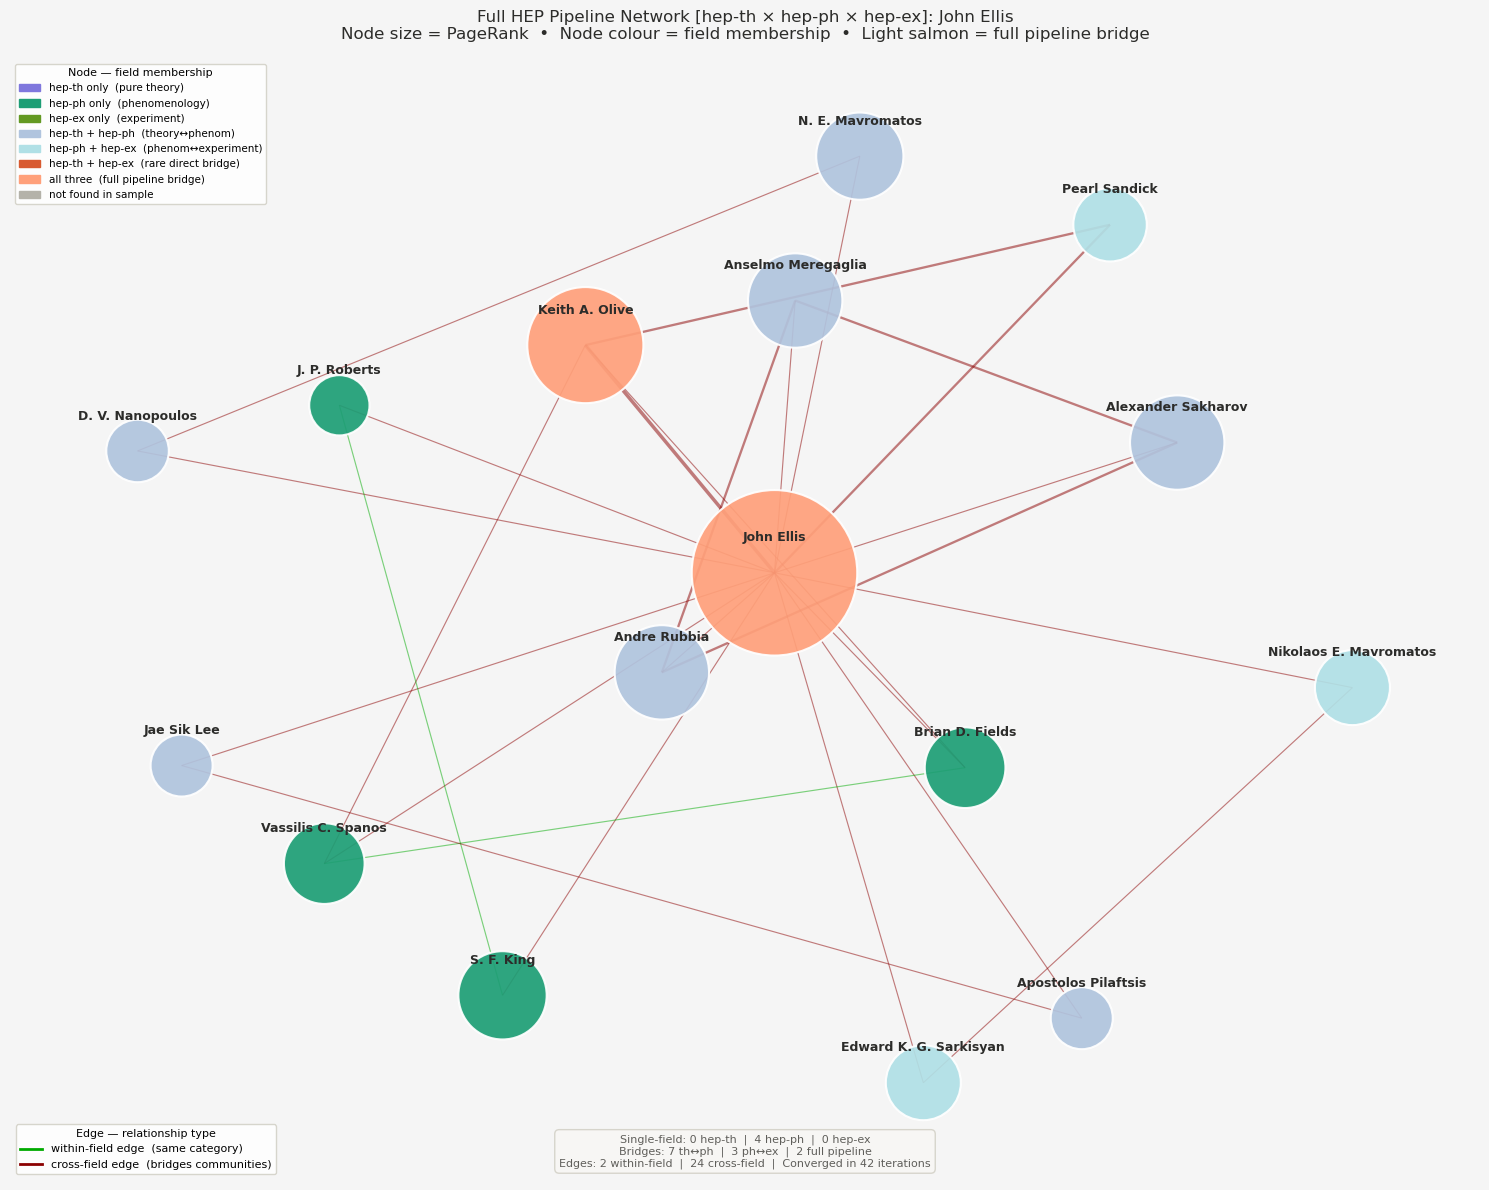

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import json
import kaggle
import findspark
from itertools import combinations
from pyspark.sql import SparkSession
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import sys, pyspark, pandas as pd, numpy as np

print("Python:  ", sys.version)
print("PySpark: ", pyspark.__version__)
print("Pandas:  ", pd.__version__)



# --- 1. KAGGLE AUTHENTICATION ---
os.environ['KAGGLE_USERNAME'] = "xxxxxx"
os.environ['KAGGLE_KEY']      = "xxxxxx"

try:
    kaggle.api.authenticate()
    print("Kaggle Authenticated Successfully.")
except Exception as e:
    print(f"Auth Error: {e}")

# --- 2. DOWNLOAD DATASET ---
dataset = "Cornell-University/arxiv"
if not os.path.exists("arxiv-metadata-oai-snapshot.json"):
    print("Downloading dataset (approx 4GB)...")
    kaggle.api.dataset_download_files(dataset, path='.', unzip=True)
else:
    print("Dataset found locally.")

# --- 3. SPARK & JAVA SETUP ---
os.environ["JAVA_HOME"] = r"/Users/selammahmudali/Downloads/jdk-17.0.17.jdk/Contents/Home"
findspark.init()

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("ArxivAuthorPageRank") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# SparkSession is required to initialise the SparkContext on local mode.
# All RDD operations use sc directly; spark itself is not called further.
sc = spark.sparkContext
sc.setLogLevel("ERROR")
print(f"Spark {spark.version} ready.")
# --- 4. DATA LOADING ---
# sc.textFile is lazy — nothing is read from disk yet.
# Sampling happens in Step 5 at the point of parsing.
sample_fraction = 0.05
print(f"Loading data (will sample {sample_fraction * 100}% in Step 5)...")
raw_rdd = sc.textFile("arxiv-metadata-oai-snapshot.json")

# ── DATA PROCESSING PATTERNS ─────────────────────────────────────────────────
# This pattern scans text for keywords that suggest an organizational
# affiliation. 'Collaboration' was also included in the search because it
# appears in many papers in the authors lists.
INSTITUTION_PATTERN = re.compile(
    r'(university|institute|dept|department|laboratory|lab|center|collaboration|centre|school|college|inc\.|ltd\.|gmbh|research|academy|office|division)',
    re.IGNORECASE
)

# This pattern looks for geographic identifiers — country names
# (USA, UK, Germany...), major cities (London, Paris, Tokyo...), and famous
# research locations (Harvard, MIT, CERN, Garching).
GEO_PATTERN = re.compile(
    r'\b(usa|uk|germany|china|japan|france|italy|russia|canada|spain|brazil|india|moscow|london|paris|tokyo|berlin|cambridge|oxford|harvard|mit|cern|garching)\b',
    re.IGNORECASE
)

# Target categories: this project focuses on the High Energy Physics category
# which includes: theorists (hep-th), phenomenologists (hep-ph) and
# experimentalists (hep-ex).
TARGET_CATEGORIES = ['hep-ph', 'hep-ex', 'hep-th']


def extract_authors_with_categories(line):
    """
    Returns (author_list, frozenset_of_categories) for HEP papers.
    Category set is built from the same JSON read as the author extraction —
    zero extra I/O cost. frozenset is used so the value is hashable for
    reduceByKey and dict keys.
    """
    try:
        data       = json.loads(line)
        categories = data.get('categories', '').lower()

        has_th = 'hep-th' in categories
        has_ph = 'hep-ph' in categories
        has_ex = 'hep-ex' in categories

        if not (has_th or has_ph or has_ex):
            return ([], frozenset())

        paper_cats = frozenset(
            cat for cat, present in
            [('hep-th', has_th), ('hep-ph', has_ph), ('hep-ex', has_ex)]
            if present
        )

        authors_parsed = data.get('authors_parsed', [])
        cleaned_list   = []

        if authors_parsed:
            for parts in authors_parsed:
                last  = parts[0].strip() if len(parts) > 0 else ''
                first = parts[1].strip() if len(parts) > 1 else ''
                if last and first:
                    full_name = f"{first} {last}".strip().strip('.,()[] ')
                    if full_name and 'et al' not in full_name.lower():
                        cleaned_list.append(full_name)
        else:
            # Fallback: use the raw authors string column
            authors_str = data.get('authors', '')
            authors_str = re.sub(r'\(.*?\)', '', authors_str)
            authors_str = authors_str.replace(' and ', ',').replace(';', ',')
            for name in [a.strip() for a in authors_str.split(',')]:
                name = name.strip('.,()[] ')
                if not name or 'et al' in name.lower():
                    continue
                if INSTITUTION_PATTERN.search(name) or GEO_PATTERN.search(name):
                    continue
                if 2 < len(name) < 60:
                    cleaned_list.append(name.title())

        return (cleaned_list, paper_cats)
    except Exception as e:
        print(f"Warning: failed to process — {e}")
        return ([], frozenset())


# --- 5. SAMPLE + PARSE ---
# .sample() is where the 5% is actually drawn from the 4GB file.
# Parsing and sampling happen in one pass — the file is read exactly once.
# Cached because Steps 5a and 5b both consume it.
parsed_rdd = raw_rdd.sample(False, sample_fraction, seed=42) \
                    .map(extract_authors_with_categories) \
                    .filter(lambda x: len(x[0]) > 1) \
                    .cache()

# ── 5a. AUTHOR → CATEGORY MAP ────────────────────────────────────────────────
# Free side-product of the parse — no extra RDD scan.
# Emit (author, paper_cats) per author per paper, then union frozensets
# so each author accumulates all categories they've ever published in.
author_category_rdd = parsed_rdd \
    .flatMap(lambda x: [(author, x[1]) for author in x[0]]) \
    .reduceByKey(lambda a, b: a | b) \
    .cache()

# ── 5b. EDGE CONSTRUCTION ────────────────────────────────────────────────────
author_groups = parsed_rdd.map(lambda x: x[0])

edges    = author_groups.flatMap(lambda x: list(combinations(x, 2)))
bi_edges = edges.flatMap(lambda x: [(x[0], x[1]), (x[1], x[0])]).cache()

edge_weights = bi_edges.map(lambda x: (x, 1)) \
                       .reduceByKey(lambda a, b: a + b)

links = edge_weights.map(lambda x: (x[0][0], (x[0][1], x[1]))) \
                    .groupByKey() \
                    .mapValues(list) \
                    .cache()

# --- 6. COMMUNICATION COST MEASUREMENT ---
N          = links.count()
num_edges  = bi_edges.count()
avg_degree = num_edges / N if N > 0 else 0

print(f"\n--- Graph Stats ---")
print(f"Nodes (N):               {N}")
print(f"Directed Edges (E):      {num_edges}")
print(f"Avg degree:              {avg_degree:.2f}")
print(f"Cost per iteration:      {num_edges} messages  → O(E)")
print(f"-------------------\n")

# --- 7. PAGERANK WITH L2 CONVERGENCE ---

def l2distance(v, q):
    """
    Computes the Euclidean distance between two rank dicts {author: rank}.

    Adapted from the numpy-array version to work with string author keys —
    no integer indexing or author-to-index mapping required.

    Args:
        v: dict {author: rank}  (old ranks)
        q: dict {author: rank}  (new ranks)

    Returns:
        Euclidean distance between v and q over their shared keys,
        used to determine when ranks have converged.

    Raises:
        ValueError if the key sets differ (graph structure must be stable).
    """
    if set(v.keys()) != set(q.keys()):
        raise ValueError('Rank dicts have different key sets — '
                         'graph structure must be stable across iterations.')
    return sum((q[author] - v[author]) ** 2 for author in v) ** 0.5


# ── 7a. PRECOMPUTE TRANSITION MATRIX ─────────────────────────────────────────
# Emit (source, target, mij) where mij = weight(source→target) / total_weight(source).
# Computed ONCE before the loop — avoids the repeated sum(w for _, w in ...)
# call that previously ran inside the flatMap on every iteration.
# transition_rdd is cached and never recomputed during the loop.
transition_rdd = links.flatMap(
    lambda x: [
        (x[0], tgt, weight / sum(w for _, w in x[1]))
        for tgt, weight in x[1]
    ]
).cache()

# ── 7b. INITIALISE ───────────────────────────────────────────────────────────
# page_rank and old_page_rank are plain Python dicts {author: float}.
# Uniform initialisation at 1/N; old_page_rank at 1.0 so the initial
# l2distance is large enough to enter the while loop.
all_authors   = links.keys().collect()
page_rank     = {author: 1.0 / N for author in all_authors}
old_page_rank = {author: 1.0     for author in all_authors}

d              = 0.85
tolerance      = 10e-7
max_iterations = 1000
iteration      = 0

dist = l2distance(old_page_rank, page_rank)

print(f"Starting PageRank (tolerance={tolerance}, max_iter={max_iterations})")
print(f"Initial L2 distance: {dist:.8f}\n")

# ── 7c. CONVERGENCE LOOP ─────────────────────────────────────────────────────
while dist >= tolerance and iteration < max_iterations:
    old_page_rank = page_rank

    # Broadcast current rank dict to all executors — avoids re-serialising
    # page_rank on every task. The broadcast is destroyed after each iteration
    # to avoid accumulating stale broadcasts in executor memory.
    rank_broadcast = sc.broadcast(page_rank)

    # (source, target, mij) → (target, mij * rank[source])
    # reduceByKey sums all incoming contributions per target author.
    # mapValues applies damping: rank(v) = (1-d)/N + d * sum_u(mij * rank[u])
    new_rank_values = (
        transition_rdd
        .map(lambda t: (t[1], t[2] * rank_broadcast.value[t[0]]))
        .reduceByKey(lambda a, b: a + b)
        .mapValues(lambda r: (1 - d) / N + d * r)
        .collect()
    )

    rank_broadcast.unpersist()   # free executor memory before next iteration

    page_rank = dict(new_rank_values)

    iteration += 1
    dist = l2distance(old_page_rank, page_rank)
    print(f"Iteration {iteration:4d}  |  L2 dist: {dist:.2e}")

print(f"\nConverged after {iteration} iterations (final dist={dist:.2e})")

# ── 7d. NORMALISE AND CONVERT BACK TO RDD ────────────────────────────────────
# Normalise so top author = 1.0 for interpretable relative scores.
# Rebuild as an RDD for downstream compatibility (Steps 8, 9, 10).
max_rank  = max(page_rank.values())
page_rank = {author: r / max_rank for author, r in page_rank.items()}
ranks     = sc.parallelize(list(page_rank.items())).cache()

# --- 8. TOP AUTHORS ---
top_authors = ranks.sortBy(lambda x: -x[1]).take(10)
print("\nTop 10 Authors by PageRank:")
for author, rank in top_authors:
    print(f"  {author}: {rank:.6f}")

# --- 9. SET TARGET AUTHOR DYNAMICALLY ---
target_author, target_rank = ranks.sortBy(lambda x: -x[1]).first()
print(f"\nTarget author for visualization: {target_author} (rank: {target_rank:.6f})")

# --- 10. VISUALIZATION ---

# ── 10a. FIND TOP COLLABORATORS ──────────────────────────────────────────────
strong_neighbors = bi_edges.filter(lambda x: x[0] == target_author) \
    .map(lambda x: (x[1], 1)) \
    .reduceByKey(lambda a, b: a + b) \
    .sortBy(lambda x: x[1], ascending=False) \
    .take(15)

neighbor_names   = [n[0] for n in strong_neighbors]
expanded_authors = [target_author] + neighbor_names
expanded_set     = set(expanded_authors)

# ── 10b. COLLECT CATEGORY MAP FOR VIZ NODES ──────────────────────────────────
author_category_map = dict(
    author_category_rdd
    .filter(lambda x: x[0] in expanded_set)
    .collect()
)

print("\nCategory membership for visualisation nodes:")
for author in sorted(expanded_set):
    cats = author_category_map.get(author, frozenset())
    print(f"  {author}: {set(cats) if cats else 'not found in sample'}")

# ── 10c. COLOUR SCHEME ───────────────────────────────────────────────────────
# Colour logic: three field anchors (purple, teal, green) chosen as visually
# distinct cool/neutral hues. Two-field bridges interpolate between their
# parents. Light salmon stands apart from all three anchors for full bridges.
# Edge colours use bright green and dark red — neither clashes with node colours.
COLOR_TH    = "#7F77DD"   # purple       — hep-th only          (pure theory)
COLOR_PH    = "#1D9E75"   # teal         — hep-ph only          (phenomenology)
COLOR_EX    = "#639922"   # green        — hep-ex only          (experiment)
COLOR_TH_PH = "#B0C4DE"   # steel blue   — hep-th + hep-ph      (theory↔phenom bridge)
COLOR_PH_EX = "#B0E0E6"   # powder blue  — hep-ph + hep-ex      (phenom↔experiment bridge)
COLOR_TH_EX = "#D85A30"   # coral        — hep-th + hep-ex      (rare skip-level bridge)
COLOR_ALL   = "#FFA07A"   # light salmon — all three            (full pipeline bridge)
COLOR_UNK   = "#B4B2A9"   # gray         — not found in sample

EDGE_WITHIN = "#00AA00"   # bright green — both endpoints same single field
EDGE_CROSS  = "#8B0000"   # dark red     — cross-field (distinct from all node colours)


def node_color(author):
    cats   = author_category_map.get(author, frozenset())
    has_th = 'hep-th' in cats
    has_ph = 'hep-ph' in cats
    has_ex = 'hep-ex' in cats
    if has_th and has_ph and has_ex: return COLOR_ALL
    if has_th and has_ph:            return COLOR_TH_PH
    if has_ph and has_ex:            return COLOR_PH_EX
    if has_th and has_ex:            return COLOR_TH_EX
    if has_th:                       return COLOR_TH
    if has_ph:                       return COLOR_PH
    if has_ex:                       return COLOR_EX
    return COLOR_UNK


def node_bridge_label(author):
    cats = author_category_map.get(author, frozenset())
    if len(cats) == 3: return 'full bridge'
    if len(cats) == 2: return 'bridge'
    return None


def edge_color(u, v):
    cats_u = author_category_map.get(u, frozenset())
    cats_v = author_category_map.get(v, frozenset())
    if len(cats_u) == 1 and cats_u == cats_v:
        return EDGE_WITHIN
    return EDGE_CROSS


# ── 10d. BUILD NETWORKX GRAPH ────────────────────────────────────────────────
sub_links = links.filter(lambda x: x[0] in expanded_set).collect()


g = nx.Graph()
for author, neighs in sub_links:
    g.add_node(author)
    for neighbor, weight in neighs:
        if neighbor in expanded_set and neighbor != author:  # ← self-loop fix
            g.add_edge(author, neighbor, weight=weight)

rank_dict = dict(ranks.filter(lambda x: x[0] in expanded_set).collect())

# ── 10e. VISUAL PROPERTIES ───────────────────────────────────────────────────
pos = nx.spring_layout(g, k=1.8, seed=42)

node_colors_list  = [node_color(n) for n in g.nodes()]
node_sizes_list   = [14000 * rank_dict.get(n, 0.001) + 200 for n in g.nodes()]
edge_colors_list  = [edge_color(u, v) for u, v in g.edges()]
edge_weights_list = [g[u][v].get('weight', 1) for u, v in g.edges()]
max_w             = max(edge_weights_list) if edge_weights_list else 1
edge_widths_list  = [2.5 * w / max_w for w in edge_weights_list]

# ── 10f. DRAW ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 12))
fig.patch.set_facecolor("#F5F5F5")
ax.set_facecolor("#F5F5F5")

nx.draw_networkx_edges(g, pos, edge_color=edge_colors_list,
                       width=edge_widths_list, alpha=0.5, ax=ax)

nx.draw_networkx_nodes(g, pos, node_color=node_colors_list,
                       node_size=node_sizes_list, alpha=0.92, ax=ax,
                       edgecolors='white', linewidths=1.5)

for node, (x, y) in pos.items():
    bridge_label = node_bridge_label(node)
    cats = author_category_map.get(node, frozenset())
    is_notable = (
        node == target_author
        or bridge_label is not None
        or len(cats) == 1
    )
    ax.text(x, y + 0.06, node,
            ha='center', va='bottom',
            fontsize=9 if is_notable else 7,
            fontweight='bold' if is_notable else 'normal',
            color='#2C2C2A')

# ── 10g. LEGENDS ─────────────────────────────────────────────────────────────
node_legend = [
    mpatches.Patch(color=COLOR_TH,    label='hep-th only  (pure theory)'),
    mpatches.Patch(color=COLOR_PH,    label='hep-ph only  (phenomenology)'),
    mpatches.Patch(color=COLOR_EX,    label='hep-ex only  (experiment)'),
    mpatches.Patch(color=COLOR_TH_PH, label='hep-th + hep-ph  (theory\u2194phenom)'),
    mpatches.Patch(color=COLOR_PH_EX, label='hep-ph + hep-ex  (phenom\u2194experiment)'),
    mpatches.Patch(color=COLOR_TH_EX, label='hep-th + hep-ex  (rare direct bridge)'),
    mpatches.Patch(color=COLOR_ALL,   label='all three  (full pipeline bridge)'),
    mpatches.Patch(color=COLOR_UNK,   label='not found in sample'),
]
edge_legend = [
    Line2D([0], [0], color=EDGE_WITHIN, linewidth=2,
           label='within-field edge  (same category)'),
    Line2D([0], [0], color=EDGE_CROSS,  linewidth=2,
           label='cross-field edge  (bridges communities)'),
]

legend1 = ax.legend(handles=node_legend, title='Node \u2014 field membership',
                    loc='upper left', fontsize=7.5, title_fontsize=8,
                    framealpha=0.9, edgecolor='#D3D1C7')
ax.add_artist(legend1)
ax.legend(handles=edge_legend, title='Edge \u2014 relationship type',
          loc='lower left', fontsize=8, title_fontsize=8,
          framealpha=0.9, edgecolor='#D3D1C7')

# ── 10h. STATS ANNOTATION ────────────────────────────────────────────────────
n_th    = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-th'}))
n_ph    = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-ph'}))
n_ex    = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-ex'}))
n_th_ph = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-th', 'hep-ph'}))
n_ph_ex = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-ph', 'hep-ex'}))
n_all   = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-th', 'hep-ph', 'hep-ex'}))
n_cross  = sum(1 for c in edge_colors_list if c == EDGE_CROSS)
n_within = sum(1 for c in edge_colors_list if c == EDGE_WITHIN)

stats_text = (
    f"Single-field: {n_th} hep-th  |  {n_ph} hep-ph  |  {n_ex} hep-ex\n"
    f"Bridges: {n_th_ph} th\u2194ph  |  {n_ph_ex} ph\u2194ex  |  {n_all} full pipeline\n"
    f"Edges: {n_within} within-field  |  {n_cross} cross-field  "
    f"|  Converged in {iteration} iterations"
)
ax.text(0.5, 0.01, stats_text, transform=ax.transAxes,
        ha='center', va='bottom', fontsize=8, color='#5F5E5A',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F8F7F4',
                  edgecolor='#D3D1C7', alpha=0.9))

ax.set_title(
    f"Full HEP Pipeline Network [hep-th \u00d7 hep-ph \u00d7 hep-ex]: {target_author}\n"
    "Node size = PageRank  \u2022  Node colour = field membership  \u2022  "
    "Light salmon = full pipeline bridge",
    fontsize=12, color='#2C2C2A', pad=14
)
ax.axis('off')
plt.tight_layout()
plt.savefig("hep_three_category_graph.png", dpi=150, bbox_inches='tight')
plt.show()

